In [27]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [28]:
import numpy as np
import pickle as pkl
from plot_params import *
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from run_sim import Config
from data_modules import create_data


In [29]:
def circulant_band_matrix(S: int, A: int):
    """
    C_A = sum_{r=-A}^A P^r
    where P is the cyclic shift operator.

    Returns
    -------
    C : shape (S, S)
    """
    C = np.zeros((S, S), dtype=float)
    for i in range(S):
        for r in range(-A, A + 1):
            j = (i + r) % S
            C[i, j] = 1.0
    return C


def theoretical_ols(S: int, A: int):
    """
    Closed-form OLS:
        W = [ (1/M) C_A - (1/(S+M)) J_S
              (1/(S+M)) J_{M x S} ]
    where M = 2A+1.
    """
    M = 2 * A + 1

    C_A = circulant_band_matrix(S, A)
    J_SS = np.ones((S, S), dtype=float)
    J_MS = np.ones((M, S), dtype=float)

    W_s = (1.0 / M) * C_A - (1.0 / (S + M)) * J_SS
    W_a = (1.0 / (S + M)) * J_MS

    W_th = np.vstack([W_s, W_a])
    return W_th

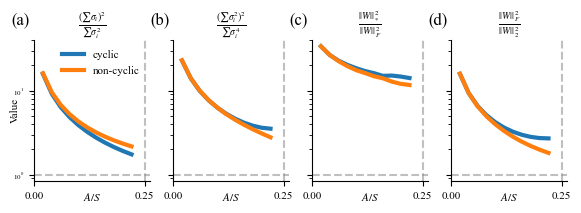

In [43]:
def calc_OLS(X, y):
    X = X.astype(np.float64)
    y = y.astype(np.float64)
    beta, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
    return beta

C = Config()
PR_circ_eigs_l = []
PR_noncirc_eigs_l = []
PR_circ_norms_l = []
PR_noncirc_norms_l = []
PR_circ_svals_l = []
PR_noncirc_svals_l = []
softrank_circ_l = []
softrank_noncirc_l = []
S = 50
inds = np.arange(0, S)
A_l = np.arange(1, S//4)
A_l_circ = A_l[A_l < S//2]
for A in A_l:
    m = 2*A + 1
    C.length_corridors = [S]
    C.max_move = A
    C.cyclic_corridors = True
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
    OLS = calc_OLS(X,y)
    OLS_circ = OLS[inds]
    C.cyclic_corridors = False
    X, y, corridor, loc_X, loc_y, action_taken, _, input_size, output_size, n_actions = create_data(C)
    OLS = calc_OLS(X,y)
    OLS_noncirc = OLS[inds]

    OLS_theory = theoretical_ols(S, A)[inds]
    # U, L, V = np.linalg.svd(OLS_theory, full_matrices=False)
    # eigs = np.linalg.eigvals(OLS_theory)
    
    tr_WTW_noncirc = np.trace(OLS_noncirc.T @ OLS_noncirc)
    tr_squared_noncirc = np.trace(OLS_noncirc)**2
    PR_noncirc_eigs_l.append(tr_squared_noncirc/tr_WTW_noncirc)
    
    frob_norm_noncirc = np.linalg.norm(OLS_noncirc, ord='fro')**2
    nuc_norm_noncirc = np.linalg.norm(OLS_noncirc, ord='nuc')**2
    PR_noncirc_norms_l.append(nuc_norm_noncirc/frob_norm_noncirc)

    tr_WTW_squared_noncirc = np.trace(OLS_noncirc.T @ OLS_noncirc)**2
    tr_WTW_W_WT_noncirc = np.trace(OLS_noncirc.T @ OLS_noncirc @ OLS_noncirc.T @ OLS_noncirc)
    PR_noncirc_svals_l.append(tr_WTW_squared_noncirc/tr_WTW_W_WT_noncirc)
    
    two_norm_noncirc = np.linalg.norm(OLS_noncirc, ord=2)
    fro_norm_noncirc = np.linalg.norm(OLS_noncirc, ord='fro')
    softrank_noncirc_l.append(fro_norm_noncirc**2/two_norm_noncirc**2)

    if A >= 0.5*S:
        continue

    #### eigenvalues PR
    tr_squared_circ = np.trace(OLS_circ)**2
    tr_WTW_circ = np.trace(OLS_circ.T @ OLS_circ)
    PR_circ_eigs_l.append(tr_squared_circ/tr_WTW_circ)

    #### norms PR
    frob_norm_circ = np.linalg.norm(OLS_circ, ord='fro')**2
    nuc_norm_circ = np.linalg.norm(OLS_circ, ord='nuc')**2
    PR_circ_norms_l.append(nuc_norm_circ/frob_norm_circ)
    

    #### singular values PR
    tr_WTW_squared_circ = np.trace(OLS_circ.T @ OLS_circ)**2
    tr_WTW_W_WT_circ = np.trace(OLS_circ.T @ OLS_circ @ OLS_circ.T @ OLS_circ)
    PR_circ_svals_l.append(tr_WTW_squared_circ/tr_WTW_W_WT_circ)

    #### soft rank
    two_norm_circ = np.linalg.norm(OLS_circ, ord=2)
    fro_norm_circ = np.linalg.norm(OLS_circ, ord='fro')
    softrank_circ_l.append(fro_norm_circ**2/two_norm_circ**2)


A_l = A_l/S
A_l_circ = A_l_circ/S
lw = 3
fig, axs = plt.subplots(1, 4, figsize=(1.25*FIG_WIDTH,FIG_WIDTH/3), sharey=True)
(ax1, ax2, ax3, ax4) = axs

ax1.plot(A_l_circ, PR_circ_eigs_l, label='cyclic', lw=lw)
ax1.plot(A_l, PR_noncirc_eigs_l, label='non-cyclic', lw=lw)
ax1.set_title(r"$\frac{(\sum \sigma_i)^2}{\sum \sigma_i^2}$")
ax1.legend()
ax1.set_ylabel('Value', labelpad=-5)

ax2.plot(A_l_circ, PR_circ_svals_l, label='cyclic', lw=lw)
ax2.plot(A_l, PR_noncirc_svals_l, label='non-cyclic', lw=lw)
ax2.set_title(r"$\frac{(\sum \sigma_i^2)^2}{\sum \sigma_i^4}$")

ax3.plot(A_l_circ, PR_circ_norms_l, label='cyclic', lw=lw)
ax3.plot(A_l, PR_noncirc_norms_l, label='non-cyclic', lw=lw)
ax3.set_title(r"$\frac{||W||_*^2}{||W||_F^2}$")

ax4.plot(A_l_circ, softrank_circ_l, label='cyclic', lw=lw)
ax4.plot(A_l, softrank_noncirc_l, label='non-cyclic', lw=lw)
ax4.set_title(r"$\frac{||W||_F^2}{||W||_2^2}$")

[[ax.axvline(val, color='gray', ls='--', alpha=0.5) for ax in axs] for val in [0.25]]
[[ax.axhline(val, color='gray', ls='--', alpha=0.5) for ax in axs] for val in [1]]
[ax.set_xticks([0, 0.25]) for ax in axs]
[ax.set_xlabel('$A/S$', labelpad=-7) for ax in axs]
[ax.set_yscale('log') for ax in axs]

panel_label(ax1, '(a)')
panel_label(ax2, '(b)')
panel_label(ax3, '(c)')
panel_label(ax4, '(d)')

fig.savefig(r'./final_results/figures/fig_OLS_comp.png', dpi=300, bbox_inches='tight')
plt.show()
